# Chapter 32: Growth Can Destroy the Engine of Growth

*Systems Thinking with AI* by Jason Karpeles

A reinforcing loop can consume the capacity that sustains it, and the warning is a ratio nobody plots.

**Goal.** Four runs of the chapter's service business. Change the hiring speed and watch the same growth policy survive or collapse, throttle intake and watch the business shrink, sweep the parameters the chapter ranks, and find the period where load first crosses one while every visible metric still looks healthy.

**Demonstrations**

1. Same growth policy, two hiring speeds
2. Throttling intake makes the business smaller
3. Which parameter decides the outcome
4. The load ratio crosses one while the dashboard is green

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/32-service-growth/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/32-service-growth/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_32_service_growth/code/growth.py`

In [2]:
%%module chapters.chapter_32_service_growth.code.growth
"""A service business where growth exposes an attrition replacement gap."""

from dataclasses import dataclass


@dataclass
class State:
    """Customers, workforce, experience, and quality at one moment."""
    customers: float = 100.0
    workforce: float = 10.0
    experience: float = 40.0     # person-years held by the workforce
    quality: float = 1.0         # 0 to 1, a capability level


@dataclass(frozen=True)
class Policy:
    """The growth and hiring settings a run is given."""
    intake_rate: float = 0.10        # new customers per existing customer per period
    hiring_aggression: float = 0.25  # fraction of the workforce gap closed per period
    quality_floor: float = 0.0       # zero-intake floor of a smooth taper; zero disables taper
    customers_per_head: float = 12.0
    ramp_years: float = 2.0
    attrition: float = 0.05
    churn_sensitivity: float = 0.6


def effective_capacity(state: State, policy: Policy) -> float:
    """Heads weighted by experience. Chapter 17's dilution, in the growth loop."""
    if state.workforce <= 0:
        return 0.0
    average = state.experience / state.workforce
    return state.workforce * min(1.0, average / policy.ramp_years) * policy.customers_per_head


def load(state: State, policy: Policy) -> float:
    """Customers divided by experience-weighted capacity."""
    capacity = effective_capacity(state, policy)
    return state.customers / capacity if capacity > 0 else float("inf")


def step(state: State, policy: Policy, dt: float = 1.0) -> State:
    """One period. All flows read the state at the start, then all stocks are written."""
    pressure = load(state, policy)
    target_quality = 1.0 / pressure if pressure > 1.0 else 1.0
    quality_change = (target_quality - state.quality) / 2.0

    # Intake is scaled down as quality approaches the floor, not switched off at it.
    # A binary switch stops growth while churn continues, which shrinks the business faster.
    headroom = 1.0
    if policy.quality_floor > 0.0:
        span = 1.0 - policy.quality_floor
        if span > 0:
            headroom = min(1.0, max(0.0, (state.quality - policy.quality_floor) / span))
        else:
            headroom = 0.0
    joining = policy.intake_rate * state.customers * state.quality * headroom
    leaving = policy.churn_sensitivity * state.customers * (1.0 - state.quality)

    desired = state.customers / policy.customers_per_head
    hiring = max(0.0, (desired - state.workforce)) * policy.hiring_aggression
    departures = policy.attrition * state.workforce
    average = state.experience / state.workforce if state.workforce > 0 else 0.0

    return State(
        customers=max(0.0, state.customers + dt * (joining - leaving)),
        workforce=max(0.0, state.workforce + dt * (hiring - departures)),
        experience=max(0.0, state.experience + dt * (state.workforce - departures * average)),
        quality=min(1.0, max(0.0, state.quality + dt * quality_change)),
    )


def run(policy: Policy, periods: int = 60, start: State | None = None) -> list[State]:
    """Advance the business and return every period's state."""
    state = start or State()
    path = [state]
    for _ in range(periods):
        state = step(state, policy)
        path.append(state)
    return path


def summary(path: list[State], policy: Policy) -> dict[str, float]:
    """The few numbers a reader should carry out of a run."""
    return {
        "final_customers": path[-1].customers,
        "peak_customers": max(s.customers for s in path),
        "final_quality": path[-1].quality,
        "min_quality": min(s.quality for s in path),
        "final_workforce": path[-1].workforce,
        "peak_load": max(load(s, policy) for s in path),
    }


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [3]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [4]:
"""Chapter 32 reader: growth that consumes the capacity that produced it.

Every number comes from the Chapter 32 pack (Policy, run, summary, load) so the reader,
the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_32_service_growth.code.growth import (
    Policy,
    effective_capacity,
    load,
    run,
    summary,
)

EQ_SLOW = "Policy(intake_rate=0.25, churn_sensitivity=1.2, hiring_aggression=0.10)"
EQ_FAST = "Policy(intake_rate=0.25, churn_sensitivity=1.2, hiring_aggression=0.25)"
EQ_SUMMARY = "summary(run(policy, 80), policy)"

PERIODS = 80


def _policy(**changes):
    base = dict(intake_rate=0.25, churn_sensitivity=1.2, hiring_aggression=0.10)
    base.update(changes)
    return Policy(**base)


def tag(ax, text, color, row=0, x=0.97):
    """A label in the empty upper right of a panel, on a white box so no line shows through."""
    ax.text(x, 0.96 - 0.095 * row, text, transform=ax.transAxes, ha="right", va="top", color=color,
            fontsize=10.5, bbox=dict(facecolor="white", edgecolor="none", alpha=0.92, pad=1.5))


def _peak_index(path):
    values = [s.customers for s in path]
    return values.index(max(values))


# Demonstration 1: the same growth policy, two hiring speeds.

def hiring_speed(hiring_aggression=0.10, intake_rate=0.25):
    policy = _policy(hiring_aggression=hiring_aggression, intake_rate=intake_rate)
    path = run(policy, PERIODS)
    stats = summary(path, policy)
    periods = np.arange(0, PERIODS + 1)
    customers = [s.customers for s in path]
    workforce = [s.workforce for s in path]
    needed = [s.customers / policy.customers_per_head for s in path]
    peak_i = _peak_index(path)
    peak, final = stats["peak_customers"], stats["final_customers"]

    fig, (left, right) = new_figure(ncols=2)
    left.plot(periods, customers, color=PALETTE["navy"])
    left.plot([peak_i], [peak], marker="o", color=PALETTE["navy"])
    top = max(customers) * 1.45
    left.set_ylim(0, top)
    left.set_xlim(0, PERIODS)
    tag(left, f"Peak {fmt(peak, 0)} in period {peak_i}", PALETTE["navy"], row=0)
    tag(left, f"Period 80: {fmt(final, 0)}", PALETTE["terracotta"], row=1)
    left.set_xlabel("Period")
    left.set_ylabel("Customers")
    left.set_title("The customer base", fontsize=11.5)

    right.plot(periods, needed, color=PALETTE["teal"], linestyle="dashed")
    right.plot(periods, workforce, color=PALETTE["terracotta"])
    ymax = max(max(needed), max(workforce)) * 1.45
    right.set_ylim(0, ymax)
    right.set_xlim(0, PERIODS)
    tag(right, "Dashed: heads the customers need", PALETTE["teal"], row=0)
    tag(right, "Solid: workforce", PALETTE["terracotta"], row=1)
    right.set_xlabel("Period")
    right.set_ylabel("Heads")
    right.set_title("Hiring against the gap", fontsize=11.5)

    state = path[peak_i]
    gap = state.customers / policy.customers_per_head - state.workforce
    hires = hiring_aggression * max(0.0, gap)
    departures = policy.attrition * state.workforce
    ratio = final / peak
    verdict = ("The business turns over and keeps shrinking." if final < 0.5 * peak
               else "The business keeps what it won.")
    metrics = {
        "Hiring aggression": fmt(hiring_aggression, 2),
        "Referral intake rate": fmt(intake_rate, 2),
        "Peak customers": fmt(peak, 1),
        "Customers after 80 periods": fmt(final, 1),
        "Lowest quality": fmt(stats["min_quality"], 2),
    }
    interpretation = (
        f"At the peak (period {peak_i}) there are {fmt(state.customers, 1)} customers, which need "
        f"{fmt(state.customers, 1)} / 12 = {fmt(state.customers / 12, 3)} heads. The workforce is "
        f"{fmt(state.workforce, 3)}, so the gap is {signed(gap, 3)} and hiring adds "
        f"{fmt(hiring_aggression, 2)} x max(0, {signed(gap, 3)}) = {fmt(hires, 3)} heads, against "
        f"0.05 x {fmt(state.workforce, 3)} = {fmt(departures, 3)} leaving. By period 80 the base is "
        f"{fmt(final, 1)} / {fmt(peak, 1)} = {fmt(ratio, 2)} of its peak. {verdict}"
    )
    alt = (
        f"Left panel: customers climb to a peak of {fmt(peak, 0)} in period {peak_i} and end at "
        f"{fmt(final, 0)} after 80 periods. Right panel: the workforce is compared with the heads the "
        f"customers need, with hiring aggression {fmt(hiring_aggression, 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: throttling intake.

def intake_throttle(quality_floor=0.0, hiring_aggression=0.10):
    policy = _policy(quality_floor=quality_floor, hiring_aggression=hiring_aggression)
    reference = _policy(hiring_aggression=hiring_aggression)
    path = run(policy, PERIODS)
    ref_path = run(reference, PERIODS)
    stats = summary(path, policy)
    ref_stats = summary(ref_path, reference)
    periods = np.arange(0, PERIODS + 1)
    customers = [s.customers for s in path]
    qualities = [s.quality for s in path]
    low_i = qualities.index(min(qualities))
    state = path[low_i]

    fig, (left, right) = new_figure(ncols=2)
    left.plot(periods, [s.customers for s in ref_path], color=PALETTE["grey"], linestyle="dashed")
    left.plot(periods, customers, color=PALETTE["navy"])
    left.set_xlim(0, PERIODS)
    left.set_ylim(0, max(max(customers), max(s.customers for s in ref_path)) * 1.45 + 1)
    tag(left, f"Solid: this run, period 80: {fmt(customers[-1], 0)}", PALETTE["navy"], row=0)
    tag(left, f"Dashed: no throttle: {fmt(ref_stats['final_customers'], 0)}", PALETTE["grey"], row=1)
    left.set_xlabel("Period")
    left.set_ylabel("Customers")
    left.set_title("Customers", fontsize=11.5)

    right.plot(periods, [s.quality for s in ref_path], color=PALETTE["grey"], linestyle="dashed")
    right.plot(periods, qualities, color=PALETTE["teal"])
    if quality_floor > 0:
        right.axhline(quality_floor, color=PALETTE["terracotta"], linewidth=1.2, linestyle="dotted")
        tag(right, f"Dotted: floor {fmt(quality_floor, 2)}", PALETTE["terracotta"], row=2)
    tag(right, "Solid: this run", PALETTE["teal"], row=0)
    tag(right, "Dashed: no throttle", PALETTE["grey"], row=1)
    right.set_xlim(0, PERIODS)
    right.set_ylim(0.4, 1.3)
    right.set_xlabel("Period")
    right.set_ylabel("Quality (0 to 1)")
    right.set_title("Quality", fontsize=11.5)

    span = 1.0 - quality_floor
    headroom = 1.0 if quality_floor <= 0 else min(1.0, max(0.0, (state.quality - quality_floor) / span))
    joining = policy.intake_rate * state.customers * state.quality * headroom
    leaving = policy.churn_sensitivity * state.customers * (1.0 - state.quality)
    net = joining - leaving
    if quality_floor <= 0:
        head_text = "no throttle, so headroom = 1.00"
    else:
        head_text = (f"headroom = ({fmt(state.quality, 2)} - {fmt(quality_floor, 2)}) / "
                     f"(1 - {fmt(quality_floor, 2)}) = {fmt(headroom, 2)}")
    smaller = stats["final_customers"] < ref_stats["final_customers"] - 1e-9
    tail = ("Quality is no worse than without the throttle and the business is smaller."
            if smaller else "This is the reference run, so there is nothing to compare it with.")
    metrics = {
        "Quality floor": fmt(quality_floor, 2) if quality_floor > 0 else "none",
        "Hiring aggression": fmt(hiring_aggression, 2),
        "Peak customers": fmt(stats["peak_customers"], 0),
        "Customers after 80 periods": fmt(stats["final_customers"], 1),
        "Lowest quality": fmt(stats["min_quality"], 2),
    }
    interpretation = (
        f"At the lowest quality (period {low_i}, quality {fmt(state.quality, 2)}, "
        f"{fmt(state.customers, 1)} customers): {head_text}. Joining = 0.25 x {fmt(state.customers, 1)} x "
        f"{fmt(state.quality, 2)} x {fmt(headroom, 2)} = {fmt(joining, 2)}. Leaving = 1.2 x "
        f"{fmt(state.customers, 1)} x (1 - {fmt(state.quality, 2)}) = {fmt(leaving, 2)}. Net = "
        f"{fmt(joining, 2)} - {fmt(leaving, 2)} = {signed(net, 2)} customers. {tail}"
    )
    alt = (
        f"Left panel: customers with the throttle, ending at {fmt(customers[-1], 0)}, against a dashed "
        f"line for no throttle ending at {fmt(ref_stats['final_customers'], 0)}. Right panel: quality "
        f"with the lowest value {fmt(stats['min_quality'], 2)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 3: which parameter decides it.

SETTINGS = {
    "churn_sensitivity": {"low": 0.6, "high": 1.8},
    "attrition": {"low": 0.03, "high": 0.08},
    "customers_per_head": {"low": 10.0, "high": 14.0},
    "ramp_years": {"low": 1.0, "high": 4.0},
}
PARAMETER_NAMES = {
    "churn_sensitivity": "Churn sensitivity to quality",
    "attrition": "Attrition rate",
    "customers_per_head": "Output per head",
    "ramp_years": "Training ramp (years)",
}


def which_parameter(parameter="churn_sensitivity", setting="low"):
    value = SETTINGS[parameter][setting]
    base_policy = _policy()
    variant = _policy(**{parameter: value})
    base_path = run(base_policy, PERIODS)
    path = run(variant, PERIODS)
    base_final = summary(base_path, base_policy)["final_customers"]
    final = summary(path, variant)["final_customers"]
    periods = np.arange(0, PERIODS + 1)
    change = final - base_final
    averages = [s.experience / s.workforce for s in path if s.workforce > 0]
    low_avg = min(averages)
    weight = min(1.0, low_avg / variant.ramp_years)

    fig, ax = new_figure()
    ax.plot(periods, [s.customers for s in base_path], color=PALETTE["grey"], linestyle="dashed")
    ax.plot(periods, [s.customers for s in path], color=PALETTE["navy"])
    top = max(max(s.customers for s in base_path), max(s.customers for s in path)) * 1.45
    ax.set_ylim(0, top)
    ax.set_xlim(0, PERIODS)
    tag(ax, f"Solid: {PARAMETER_NAMES[parameter]} {fmt(value, 2)}, ends {fmt(final, 1)}", PALETTE["navy"], row=0)
    tag(ax, f"Dashed: base run, ends {fmt(base_final, 1)}", PALETTE["grey"], row=1)
    ax.set_xlabel("Period")
    ax.set_ylabel("Customers")

    if abs(change) < 0.05:
        verdict = "The swing is zero to one decimal: this parameter does not decide the outcome."
    else:
        verdict = f"Moving {PARAMETER_NAMES[parameter].lower()} to {fmt(value, 2)} moves the outcome by {signed(change, 1)} customers."
    metrics = {
        "Parameter moved": PARAMETER_NAMES[parameter],
        "Value used": fmt(value, 2),
        "Customers after 80 periods": fmt(final, 1),
        "Base run, customers after 80 periods": fmt(base_final, 1),
        "Change from base": signed(change, 1),
        "Smallest experience weight": fmt(weight, 2),
    }
    interpretation = (
        f"Change = {fmt(final, 1)} - {fmt(base_final, 1)} = {signed(change, 1)} customers. The experience "
        f"weight is min(1, average experience / ramp); the smallest average experience in this run is "
        f"{fmt(low_avg, 2)} years against a ramp of {fmt(variant.ramp_years, 1)}, so the weight is "
        f"min(1, {fmt(low_avg, 2)} / {fmt(variant.ramp_years, 1)}) = {fmt(weight, 2)}. {verdict}"
    )
    alt = (
        f"Customers over 80 periods with {PARAMETER_NAMES[parameter].lower()} at {fmt(value, 2)}, ending "
        f"at {fmt(final, 1)}, against the dashed base run ending at {fmt(base_final, 1)}."
    )
    return fig, metrics, interpretation, alt


# Demonstration 4: the load ratio is the early signal.

def load_signal(intake_rate=0.25, hiring_aggression=0.10):
    policy = _policy(intake_rate=intake_rate, hiring_aggression=hiring_aggression)
    path = run(policy, PERIODS)
    stats = summary(path, policy)
    window = 16
    loads = [load(s, policy) for s in path]
    first = next((i for i, v in enumerate(loads) if v > 1.0), None)
    periods = np.arange(0, window + 1)

    fig, (left, right) = new_figure(ncols=2)
    left.axhline(1.0, color=PALETTE["grey"], linestyle="dotted", linewidth=1.4)
    left.plot(periods, loads[: window + 1], color=PALETTE["terracotta"], marker="o")
    left.set_ylim(0.6, max(loads[: window + 1]) * 1.4)
    left.set_xlim(-0.5, window + 0.5)
    tag(left, "Dotted line: load = 1", PALETTE["grey"], row=0)
    if first is not None and first <= window:
        tag(left, f"First above 1: period {first}", PALETTE["terracotta"], row=1)
    left.set_xlabel("Period")
    left.set_ylabel("Load (customers / capacity)")
    left.set_title("The ratio nobody plots", fontsize=11.5)

    right.plot(periods, [s.customers for s in path[: window + 1]], color=PALETTE["navy"], marker="o")
    top = max(s.customers for s in path[: window + 1])
    right.set_ylim(0, top * 1.4)
    right.set_xlim(-0.5, window + 0.5)
    tag(right, "Solid: customers", PALETTE["navy"], row=0)
    if first is not None and first <= window:
        right.axvline(first, color=PALETTE["terracotta"], linestyle="dashed", linewidth=1.2)
        tag(right, "Dashed line: load first above 1", PALETTE["terracotta"], row=1)
    right.set_xlabel("Period")
    right.set_ylabel("Customers")
    right.set_title("What the dashboard shows", fontsize=11.5)

    metrics = {"Referral intake rate": fmt(intake_rate, 2), "Hiring aggression": fmt(hiring_aggression, 2),
               "Highest load in the run": fmt(stats["peak_load"], 2)}
    if first is None:
        metrics["First period with load above 1"] = "none in this run"
        interpretation = "Load never exceeds 1 in this run, so the early warning never fires."
        alt = "Load stays at or below one."
    else:
        s = path[first]
        prev = path[first - 1]
        average = s.experience / s.workforce
        weight = min(1.0, average / policy.ramp_years)
        capacity = effective_capacity(s, policy)
        metrics["First period with load above 1"] = str(first)
        metrics["Customers in that period"] = fmt(s.customers, 1)
        metrics["Quality in that period"] = fmt(s.quality, 2)
        direction = "still rising" if s.customers > prev.customers else "not rising"
        interpretation = (
            f"In period {first} the workforce is {fmt(s.workforce, 2)} with average experience "
            f"{fmt(average, 2)} years, so the weight is min(1, {fmt(average, 2)} / 2) = {fmt(weight, 2)} and "
            f"capacity is {fmt(s.workforce, 2)} x {fmt(weight, 2)} x 12 = {fmt(capacity, 1)}. Load = "
            f"{fmt(s.customers, 1)} / {fmt(capacity, 1)} = {fmt(s.customers / capacity, 2)}, above 1. "
            f"Quality is {fmt(s.quality, 2)} and customers are {direction} "
            f"({fmt(prev.customers, 1)} to {fmt(s.customers, 1)}), so the usual dashboard looks healthy."
        )
        alt = (
            f"Left panel: load first rises above one in period {first}. Right panel: customers are "
            f"{direction} at that point, with a dashed vertical line marking the crossing."
        )
    return fig, metrics, interpretation, alt


## 1. Same growth policy, two hiring speeds

*If only the speed of hiring changes, does the business survive its own growth?*

Slow hiring leaves the workforce below what the customers need, load rises above one, quality falls and churn rises. Faster hiring closes the gap quickly enough that quality never falls below 0.71, so the same referral engine keeps its customers.

    Policy(intake_rate=0.25, churn_sensitivity=1.2, hiring_aggression=0.10)
    Policy(intake_rate=0.25, churn_sensitivity=1.2, hiring_aggression=0.25)

**Symbols and inputs.** Customers join through referral and leave through churn. Hiring aggression is the fraction of the gap between heads needed (customers / 12) and the workforce that is closed each period. Attrition removes 5 percent of the workforce per period. A period is one time step.

**Predict first.** With hiring aggression 0.10 and intake 0.25, do customers after 80 periods end above or below 50?

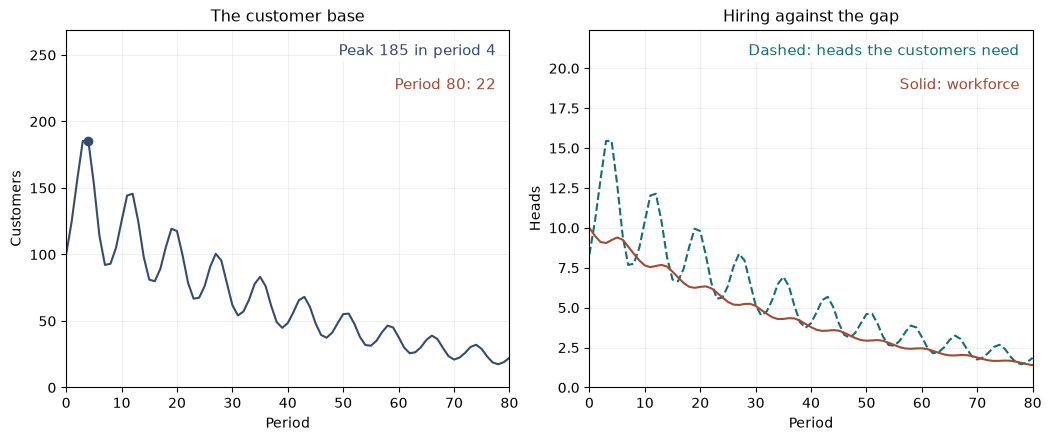

- **Hiring aggression:** 0.10
- **Referral intake rate:** 0.25
- **Peak customers:** 185.5
- **Customers after 80 periods:** 22.3
- **Lowest quality:** 0.65

At the peak (period 4) there are 185.5 customers, which need 185.5 / 12 = 15.456 heads. The workforce is 9.238, so the gap is 6.218 and hiring adds 0.10 x max(0, 6.218) = 0.622 heads, against 0.05 x 9.238 = 0.462 leaving. By period 80 the base is 22.3 / 185.5 = 0.12 of its peak. The business turns over and keeps shrinking.

In [5]:
show(hiring_speed(hiring_aggression=0.1, intake_rate=0.25))

**Use the idea.** When growth stalls and then reverses, check whether the capacity-building loop is slower than the loop that adds demand before blaming demand.

**Where the conclusion applies.** The chapter's constant parameters and a 100 customer, 10 head start. The conclusion fails if the labour market cannot supply people at the faster rate, which the model does not represent.

*Constructed example: the chapter's two printed runs and neighbouring settings, recomputed with the chapter's run and summary functions.*

Every setting the interactive reader offers for this demonstration:

In [6]:
sweep(hiring_speed, [('hiring_aggression', [0.1, 0.15, 0.2, 0.25]), ('intake_rate', [0.15, 0.25])])

- **hiring_aggression = 0.1, intake_rate = 0.15**: Hiring aggression 0.10; Referral intake rate 0.15; Peak customers 155.1; Customers after 80 periods 8.3; Lowest quality 0.74
- **hiring_aggression = 0.1, intake_rate = 0.25**: Hiring aggression 0.10; Referral intake rate 0.25; Peak customers 185.5; Customers after 80 periods 22.3; Lowest quality 0.65
- **hiring_aggression = 0.15, intake_rate = 0.15**: Hiring aggression 0.15; Referral intake rate 0.15; Peak customers 155.2; Customers after 80 periods 18.2; Lowest quality 0.75
- **hiring_aggression = 0.15, intake_rate = 0.25**: Hiring aggression 0.15; Referral intake rate 0.25; Peak customers 185.9; Customers after 80 periods 46.7; Lowest quality 0.67
- **hiring_aggression = 0.2, intake_rate = 0.15**: Hiring aggression 0.20; Referral intake rate 0.15; Peak customers 155.2; Customers after 80 periods 25.7; Lowest quality 0.76
- **hiring_aggression = 0.2, intake_rate = 0.25**: Hiring aggression 0.20; Referral intake rate 0.25; Peak customers 186.4; Customers after 80 periods 95.8; Lowest quality 0.69
- **hiring_aggression = 0.25, intake_rate = 0.15**: Hiring aggression 0.25; Referral intake rate 0.15; Peak customers 155.3; Customers after 80 periods 43.7; Lowest quality 0.77
- **hiring_aggression = 0.25, intake_rate = 0.25**: Hiring aggression 0.25; Referral intake rate 0.25; Peak customers 190.0; Customers after 80 periods 190.0; Lowest quality 0.71

## 2. Throttling intake makes the business smaller

*If sales stop when quality drops, does the business recover?*

The throttle cuts the joining flow directly. It has no direct term in the leaving flow, and the lower load it brings does lift quality and so reduce churn, but not by enough: fewer customers are replaced, so the base ends smaller.

    Policy(intake_rate=0.25, churn_sensitivity=1.2, hiring_aggression=0.10)

**Symbols and inputs.** Intake tapers smoothly as quality falls below 1 and reaches zero at the floor (the floor is not an activation threshold): headroom = (quality - floor) / (1 - floor), held between 0 and 1. Joining = intake x customers x quality x headroom. Leaving = churn sensitivity x customers x (1 - quality).

**Predict first.** With a taper that reaches zero intake at quality 0.70, do customers after 80 periods end above or below the unthrottled 22?

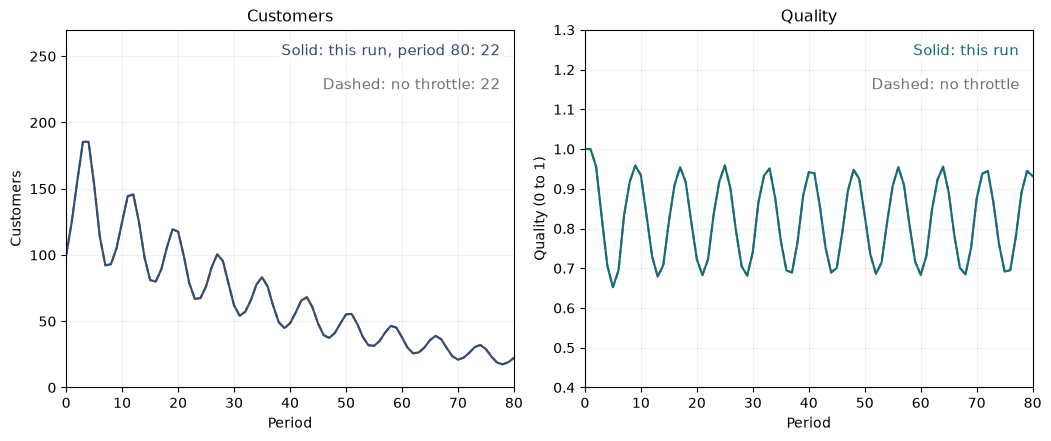

- **Quality floor:** none
- **Hiring aggression:** 0.10
- **Peak customers:** 185
- **Customers after 80 periods:** 22.3
- **Lowest quality:** 0.65

At the lowest quality (period 5, quality 0.65, 153.1 customers): no throttle, so headroom = 1.00. Joining = 0.25 x 153.1 x 0.65 x 1.00 = 24.96. Leaving = 1.2 x 153.1 x (1 - 0.65) = 63.85. Net = 24.96 - 63.85 = (-38.89) customers. This is the reference run, so there is nothing to compare it with.

In [7]:
show(intake_throttle(quality_floor=0.0, hiring_aggression=0.1))

**Use the idea.** Before restricting intake to protect quality, write down the outflow it does not act on directly and the capacity lever, hiring, that goes unused.

**Where the conclusion applies.** Throttling affects intake only. A throttle paired with service recovery aimed at churn would behave differently, and this model does not represent that.

*Constructed example: the chapter's comparison table, recomputed with the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [8]:
sweep(intake_throttle, [('quality_floor', [0.0, 0.6, 0.7]), ('hiring_aggression', [0.1, 0.25])])

- **quality_floor = 0.0, hiring_aggression = 0.1**: Quality floor none; Hiring aggression 0.10; Peak customers 185; Customers after 80 periods 22.3; Lowest quality 0.65
- **quality_floor = 0.0, hiring_aggression = 0.25**: Quality floor none; Hiring aggression 0.25; Peak customers 190; Customers after 80 periods 190.0; Lowest quality 0.71
- **quality_floor = 0.6, hiring_aggression = 0.1**: Quality floor 0.60; Hiring aggression 0.10; Peak customers 181; Customers after 80 periods 16.3; Lowest quality 0.69
- **quality_floor = 0.6, hiring_aggression = 0.25**: Quality floor 0.60; Hiring aggression 0.25; Peak customers 181; Customers after 80 periods 55.1; Lowest quality 0.74
- **quality_floor = 0.7, hiring_aggression = 0.1**: Quality floor 0.70; Hiring aggression 0.10; Peak customers 180; Customers after 80 periods 6.7; Lowest quality 0.70
- **quality_floor = 0.7, hiring_aggression = 0.25**: Quality floor 0.70; Hiring aggression 0.25; Peak customers 180; Customers after 80 periods 70.0; Lowest quality 0.74

## 3. Which parameter decides the outcome

*Which parameter moves the eighty-period customer count most, and which moves it not at all?*

Capacity weights each head by min(1, average experience / ramp). Average experience here starts at 4 years and rises, so the weight is already 1 and the ramp has nothing to change.

    summary(run(policy, 80), policy)

**Symbols and inputs.** Churn sensitivity scales how fast customers leave as quality falls. Attrition is the fraction of the workforce leaving per period. Output per head is customers one person serves. The ramp is the years of experience at which a head counts in full.

**Predict first.** Does moving the training ramp from 2 years to 1 year change the final customer count?

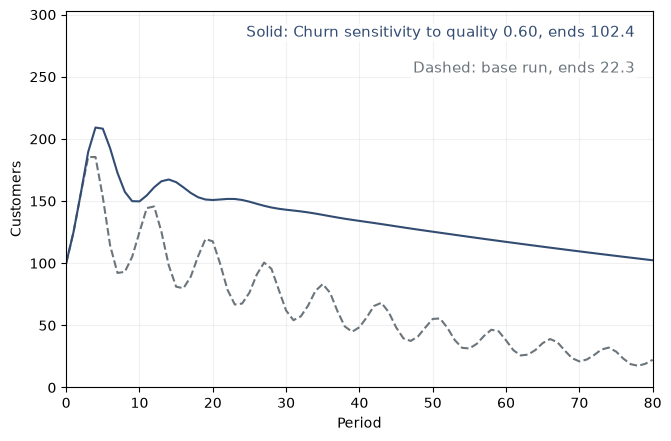

- **Parameter moved:** Churn sensitivity to quality
- **Value used:** 0.60
- **Customers after 80 periods:** 102.4
- **Base run, customers after 80 periods:** 22.3
- **Change from base:** 80.1
- **Smallest experience weight:** 1.00

Change = 102.4 - 22.3 = 80.1 customers. The experience weight is min(1, average experience / ramp); the smallest average experience in this run is 4.00 years against a ramp of 2.0, so the weight is min(1, 4.00 / 2.0) = 1.00. Moving churn sensitivity to quality to 0.60 moves the outcome by 80.1 customers.

In [9]:
show(which_parameter(parameter='churn_sensitivity', setting='low'))

**Use the idea.** Rank parameters by how far the outcome swings before spending an afternoon measuring one. A parameter that never binds is not worth measuring for this decision.

**Where the conclusion applies.** Each parameter is moved alone from the slow-hiring base run. The ramp's zero swing holds only while average experience stays above the ramp, and a workforce of new hires could change that.

*Constructed example: the chapter's parameter ranges, recomputed one at a time with the chapter's run function.*

Every setting the interactive reader offers for this demonstration:

In [10]:
sweep(which_parameter, [('parameter', ['churn_sensitivity', 'attrition', 'customers_per_head', 'ramp_years']), ('setting', ['low', 'high'])])

- **parameter = churn_sensitivity, setting = low**: Parameter moved Churn sensitivity to quality; Value used 0.60; Customers after 80 periods 102.4; Base run, customers after 80 periods 22.3; Change from base 80.1; Smallest experience weight 1.00
- **parameter = churn_sensitivity, setting = high**: Parameter moved Churn sensitivity to quality; Value used 1.80; Customers after 80 periods 6.9; Base run, customers after 80 periods 22.3; Change from base (-15.5); Smallest experience weight 1.00
- **parameter = attrition, setting = low**: Parameter moved Attrition rate; Value used 0.03; Customers after 80 periods 85.4; Base run, customers after 80 periods 22.3; Change from base 63.1; Smallest experience weight 1.00
- **parameter = attrition, setting = high**: Parameter moved Attrition rate; Value used 0.08; Customers after 80 periods 2.9; Base run, customers after 80 periods 22.3; Change from base (-19.4); Smallest experience weight 1.00
- **parameter = customers_per_head, setting = low**: Parameter moved Output per head; Value used 10.00; Customers after 80 periods 20.0; Base run, customers after 80 periods 22.3; Change from base (-2.3); Smallest experience weight 1.00
- **parameter = customers_per_head, setting = high**: Parameter moved Output per head; Value used 14.00; Customers after 80 periods 22.4; Base run, customers after 80 periods 22.3; Change from base 0.1; Smallest experience weight 1.00
- **parameter = ramp_years, setting = low**: Parameter moved Training ramp (years); Value used 1.00; Customers after 80 periods 22.3; Base run, customers after 80 periods 22.3; Change from base 0.0; Smallest experience weight 1.00
- **parameter = ramp_years, setting = high**: Parameter moved Training ramp (years); Value used 4.00; Customers after 80 periods 22.3; Base run, customers after 80 periods 22.3; Change from base 0.0; Smallest experience weight 1.00

## 4. The load ratio crosses one while the dashboard is green

*In which period does load first exceed one, and what do customers and quality look like then?*

Customers grow by about a quarter each period while the workforce shrinks slightly through attrition, so load passes one almost immediately. Quality lags load by a couple of periods, so it still reads 1.00 when the ratio has already crossed.

    summary(run(policy, 80), policy)

**Symbols and inputs.** Load is customers divided by effective capacity. Effective capacity is workforce x min(1, average experience / 2) x 12 customers per head. Quality runs from 0 to 1.

**Predict first.** With intake 0.25 and hiring aggression 0.10, in which period does load first exceed one?

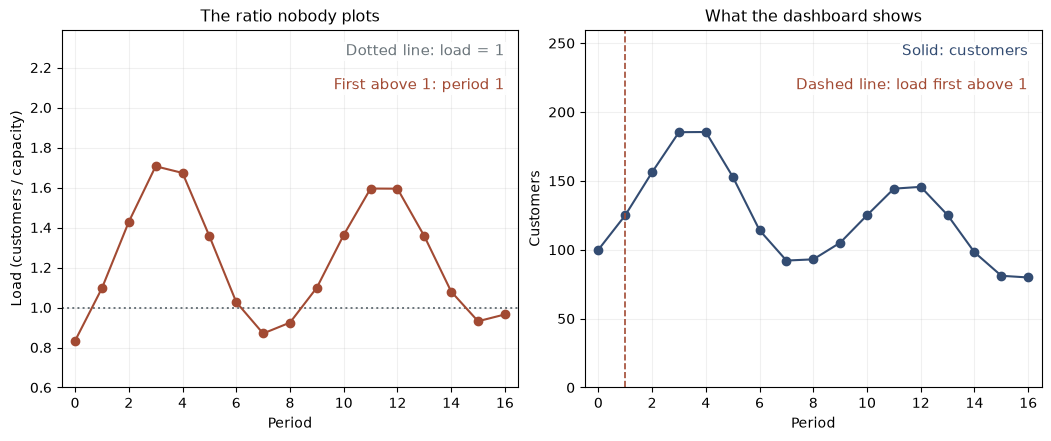

- **Referral intake rate:** 0.25
- **Hiring aggression:** 0.10
- **Highest load in the run:** 1.71
- **First period with load above 1:** 1
- **Customers in that period:** 125.0
- **Quality in that period:** 1.00

In period 1 the workforce is 9.50 with average experience 5.05 years, so the weight is min(1, 5.05 / 2) = 1.00 and capacity is 9.50 x 1.00 x 12 = 114.0. Load = 125.0 / 114.0 = 1.10, above 1. Quality is 1.00 and customers are still rising (100.0 to 125.0), so the usual dashboard looks healthy.

In [11]:
show(load_signal(intake_rate=0.25, hiring_aggression=0.1))

**Use the idea.** Plot the ratio of demand to experience-weighted capacity weekly with a line at one, and trigger hiring on it.

**Where the conclusion applies.** The chapter's parameters and a first crossing found on the period-end states. With a slower referral rate the crossing comes later, and with no growth it may never come.

*Constructed example: the chapter's period-by-period walk, recomputed with the chapter's load and effective_capacity functions.*

Every setting the interactive reader offers for this demonstration:

In [12]:
sweep(load_signal, [('intake_rate', [0.15, 0.25, 0.35]), ('hiring_aggression', [0.1, 0.25])])

- **intake_rate = 0.15, hiring_aggression = 0.1**: Referral intake rate 0.15; Hiring aggression 0.10; Highest load in the run 1.48; First period with load above 1 1; Customers in that period 115.0; Quality in that period 1.00
- **intake_rate = 0.15, hiring_aggression = 0.25**: Referral intake rate 0.15; Hiring aggression 0.25; Highest load in the run 1.39; First period with load above 1 1; Customers in that period 115.0; Quality in that period 1.00
- **intake_rate = 0.25, hiring_aggression = 0.1**: Referral intake rate 0.25; Hiring aggression 0.10; Highest load in the run 1.71; First period with load above 1 1; Customers in that period 125.0; Quality in that period 1.00
- **intake_rate = 0.25, hiring_aggression = 0.25**: Referral intake rate 0.25; Hiring aggression 0.25; Highest load in the run 1.59; First period with load above 1 1; Customers in that period 125.0; Quality in that period 1.00
- **intake_rate = 0.35, hiring_aggression = 0.1**: Referral intake rate 0.35; Hiring aggression 0.10; Highest load in the run 2.00; First period with load above 1 1; Customers in that period 135.0; Quality in that period 1.00
- **intake_rate = 0.35, hiring_aggression = 0.25**: Referral intake rate 0.35; Hiring aggression 0.25; Highest load in the run 1.79; First period with load above 1 1; Customers in that period 135.0; Quality in that period 1.00

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With intake 0.25 and hiring aggression 0.25, do customers after 80 periods end above or below 100?

<details><summary>Answer</summary>

Above: the run ends at 190.0, while the slow-hiring run ends at 22.3 after peaking near 185.

</details>

### Exercise 2

At quality 0.65 with a floor of 0.60, what is the headroom?

<details><summary>Answer</summary>

(0.65 - 0.60) / (1 - 0.60) = 0.05 / 0.40 = 0.125, so intake runs at one eighth of its usual rate.

</details>

### Exercise 3

If average experience were 1.0 year against a ramp of 2 years, what weight would each head carry?

<details><summary>Answer</summary>

min(1, 1.0 / 2) = 0.5, so each head would count as half a head.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/